# Terceira Etapa: Clusterizacao

Nesta etapa, aplicaremos algoritmos de clusterizacao aos dados transformados do ENEM.

## Algoritmos utilizados:
1. **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)
2. **K-Means**

## Objetivos:
- Identificar grupos naturais nos dados
- Comparar os resultados dos dois algoritmos
- Analisar as caracteristicas de cada cluster

## 1. Imports e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Carregando os dados transformados
df = pd.read_csv('dados_transformados_clusterizacao_v2.csv')
print(f'Shape dos dados: {df.shape}')
print(f'\nColunas: {list(df.columns)}')
df.head()

Shape dos dados: (128546, 35)

Colunas: ['esc_mae', 'esc_pai', 'tem_computador_notebook', 'tem_carro', 'faixa_etaria', 'renda_log', 'pessoas_residencia', 'total_bens', 'ano_conclusao', 'tem_internet_wifi', 'possui_renda', 'treineiro', 'sexo_M', 'estado_civil_1', 'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'cor_raca_1', 'cor_raca_2', 'cor_raca_3', 'cor_raca_4', 'cor_raca_5', 'nacionalidade_1', 'nacionalidade_2', 'nacionalidade_3', 'nacionalidade_4', 'status_conclusao_2', 'status_conclusao_3', 'status_conclusao_4', 'tipo_ensino_2.0', 'tipo_escola_B', 'tipo_escola_C', 'tipo_escola_D', 'tipo_escola_E', 'tipo_escola_F']


,esc_mae,esc_pai,tem_computador_notebook,tem_carro,faixa_etaria,renda_log,pessoas_residencia,total_bens,ano_conclusao,tem_internet_wifi,...,nacionalidade_4,status_conclusao_2,status_conclusao_3,status_conclusao_4,tipo_ensino_2.0,tipo_escola_B,tipo_escola_C,tipo_escola_D,tipo_escola_E,tipo_escola_F
0,-0.873158,1.110526,-0.665966,-0.607671,1.700916,0.339509,0.17666,-0.585828,2.360867,0.403819,...,-0.038575,-0.653407,-0.506274,-0.078736,-0.041593,-0.195324,-0.133141,-0.417378,-0.19145,-0.061349
1,-0.873158,0.491400,0.595153,-0.607671,-0.053579,0.551257,-0.53076,-0.154463,-0.564944,0.403819,...,-0.038575,-0.653407,-0.506274,-0.078736,-0.041593,-0.195324,-0.133141,-0.417378,-0.19145,-0.061349
2,-0.873158,-1.365977,-0.665966,-0.607671,0.948989,0.339509,0.17666,-0.370145,0.688975,0.403819,...,-0.038575,-0.653407,-0.506274,-0.078736,-0.041593,-0.195324,-0.133141,-0.417378,-0.19145,-0.061349
3,1.515557,1.729651,3.117390,1.096676,-0.554864,1.070278,0.17666,2.218048,-0.355958,0.403819,...,-0.038575,-0.653407,-0.506274,-0.078736,-0.041593,-0.195324,-0.133141,2.395911,-0.19145,-0.061349
4,-0.275979,-0.746851,-0.665966,-0.607671,3.455411,0.259139,-1.94560,-0.154463,-0.564944,0.403819,...,-0.038575,-0.653407,-0.506274,12.700612,-0.041593,-0.195324,-0.133141,-0.417378,-0.19145,-0.061349


In [3]:
# Verificando valores nulos
print('Valores nulos por coluna:')
print(df.isnull().sum().sum())

# Estatisticas descritivas
df.describe()

Valores nulos por coluna:
0


,esc_mae,esc_pai,tem_computador_notebook,tem_carro,faixa_etaria,renda_log,pessoas_residencia,total_bens,ano_conclusao,tem_internet_wifi,...,nacionalidade_4,status_conclusao_2,status_conclusao_3,status_conclusao_4,tipo_ensino_2.0,tipo_escola_B,tipo_escola_C,tipo_escola_D,tipo_escola_E,tipo_escola_F
count,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,...,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05,1.285460e+05
mean,-1.857252e-17,-9.242041e-17,-1.857252e-17,3.559734e-17,1.140884e-16,-1.569157e-15,1.227113e-15,-3.708756e-15,-5.209151e-16,6.677264e-17,...,4.178818e-17,1.415049e-17,4.068267e-17,6.212951e-17,1.143095e-16,6.677264e-17,3.029090e-17,-3.802945e-17,-1.326609e-17,-4.753682e-18
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.470336e+00,-1.985102e+00,-6.659659e-01,-6.076706e-01,-1.056148e+00,-2.355016e+00,-1.945600e+00,-2.311291e+00,-5.649444e-01,-2.476354e+00,...,-3.857539e-02,-6.534074e-01,-5.062742e-01,-7.873636e-02,-4.159322e-02,-1.953242e-01,-1.331415e-01,-4.173777e-01,-1.914496e-01,-6.134935e-02
25%,-8.731575e-01,-7.468510e-01,-6.659659e-01,-6.076706e-01,-8.055056e-01,2.591390e-01,-5.307601e-01,-5.858282e-01,-5.649444e-01,4.038194e-01,...,-3.857539e-02,-6.534074e-01,-5.062742e-01,-7.873636e-02,-4.159322e-02,-1.953242e-01,-1.331415e-01,-4.173777e-01,-1.914496e-01,-6.134935e-02
50%,-2.759790e-01,4.914002e-01,-6.659659e-01,-6.076706e-01,-3.042214e-01,2.591390e-01,1.766596e-01,-1.544626e-01,-5.649444e-01,4.038194e-01,...,-3.857539e-02,-6.534074e-01,-5.062742e-01,-7.873636e-02,-4.159322e-02,-1.953242e-01,-1.331415e-01,-4.173777e-01,-1.914496e-01,-6.134935e-02
75%,9.183782e-01,4.914002e-01,5.951527e-01,1.096676e+00,4.477051e-01,3.395091e-01,1.766596e-01,4.925859e-01,6.201508e-02,4.038194e-01,...,-3.857539e-02,1.530439e+00,-5.062742e-01,-7.873636e-02,-4.159322e-02,-1.953242e-01,-1.331415e-01,-4.173777e-01,-1.914496e-01,-6.134935e-02
max,2.112735e+00,1.729651e+00,4.378509e+00,4.505370e+00,3.706053e+00,1.415903e+00,1.149537e+01,4.590559e+00,3.196813e+00,4.038194e-01,...,2.592327e+01,1.530439e+00,1.975214e+00,1.270061e+01,2.404238e+01,5.119694e+00,7.510808e+00,2.395911e+00,5.223308e+00,1.630009e+01


## 2. Preparacao dos Dados para Clusterizacao

In [4]:
# Convertendo para array numpy
X = df.values
print(f'Shape do array: {X.shape}')

Shape do array: (128546, 35)


## 3. DBSCAN

O DBSCAN e um algoritmo baseado em densidade que nao requer especificar o numero de clusters a priori.

### Parametros principais:
- **eps**: Distancia maxima entre dois pontos para serem considerados vizinhos
- **min_samples**: Numero minimo de pontos para formar uma regiao densa

### 3.1 Encontrando o valor ideal de eps (metodo k-distance)

In [5]:
# Usando uma amostra para calcular k-distance (dataset grande)
sample_size = min(10000, len(X))
np.random.seed(42)
sample_indices = np.random.choice(len(X), sample_size, replace=False)
X_sample = X[sample_indices]

print(f'Usando amostra de {sample_size} registros para calcular k-distance')

Usando amostra de 10000 registros para calcular k-distance


k utilizado: 50
Distância máxima: 42.4793
Distância média: 3.3537


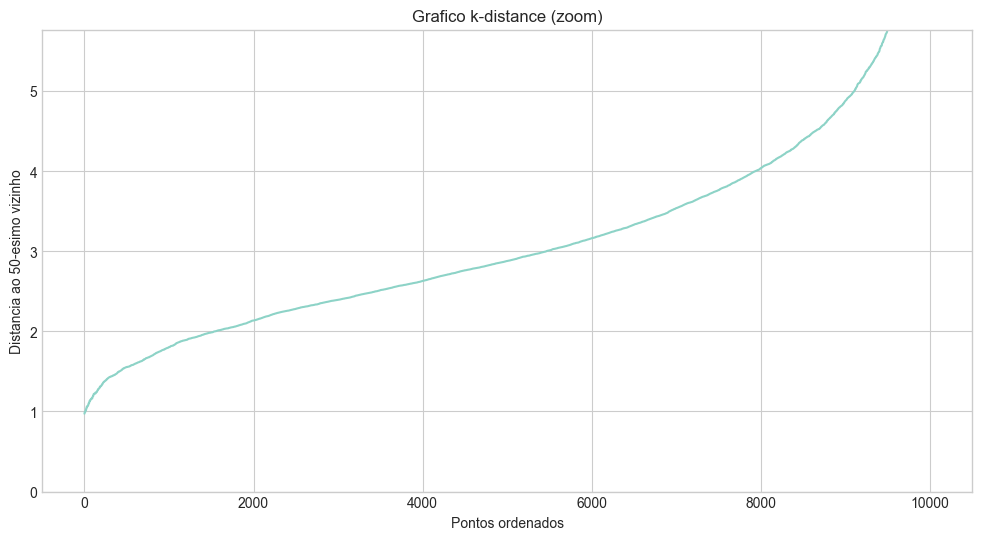

In [6]:
# Zoom no grafico para identificar melhor o cotovelo
# Calculando k-distance para encontrar eps ideal
k = 2 * X_sample.shape[1]  # Regra comum: k = 2 * dimensões
k = min(k, 50)  # Limitando para não ficar muito grande
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_sample)
distances, indices = neighbors.kneighbors(X_sample)                                                                                   # Pegando a distância ao k-ésimo vizinho e ordenando
distances = np.sort(distances[:, k-1])
print(f'k utilizado: {k}')
print(f'Distância máxima: {distances.max():.4f}')
print(f'Distância média: {distances.mean():.4f}')
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distancia ao {k}-esimo vizinho')
plt.title('Grafico k-distance (zoom)')
plt.ylim(0, np.percentile(distances, 95))  # Limitando ao percentil 95
plt.grid(True)
plt.show()

### 3.2 Testando diferentes valores de eps

In [7]:
# Testando diferentes valores de eps na amostra
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples_values = [5, 10, 15, 20]

resultados_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_sample)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # Silhouette score (apenas se houver mais de 1 cluster e menos que 100% ruido)
        if n_clusters > 1 and noise_ratio < 1:
            # Removendo pontos de ruido para calcular silhouette
            mask = labels != -1
            if mask.sum() > 1:
                silhouette = silhouette_score(X_sample[mask], labels[mask])
            else:
                silhouette = -1
        else:
            silhouette = -1
        
        resultados_dbscan.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette
        })

df_resultados_dbscan = pd.DataFrame(resultados_dbscan)
print('Resultados dos testes DBSCAN:')
df_resultados_dbscan

Resultados dos testes DBSCAN:


,eps,min_samples,n_clusters,n_noise,noise_ratio,silhouette
0,0.5,5,25,9826,0.9826,0.601286
1,0.5,10,2,9971,0.9971,0.805115
2,0.5,15,1,9984,0.9984,-1.000000
3,0.5,20,0,10000,1.0000,-1.000000
4,1.0,5,135,7044,0.7044,0.245953
5,1.0,10,36,8270,0.8270,0.315669
6,1.0,15,17,8822,0.8822,0.377510
7,1.0,20,8,9242,0.9242,0.407347
8,1.5,5,159,4610,0.4610,0.243992
9,1.5,10,71,5809,0.5809,0.260213


In [8]:
# Filtrando resultados com clusters validos
df_valid = df_resultados_dbscan[(df_resultados_dbscan['n_clusters'] >= 2) & 
                                 (df_resultados_dbscan['noise_ratio'] < 0.5) &
                                 (df_resultados_dbscan['silhouette'] > 0)]

print('Melhores configuracoes (2+ clusters, <50% ruido, silhouette > 0):')
df_valid.sort_values('silhouette', ascending=False).head(10)

Melhores configuracoes (2+ clusters, <50% ruido, silhouette > 0):


,eps,min_samples,n_clusters,n_noise,noise_ratio,silhouette
31,4.0,20,9,561,0.0561,0.253950
8,1.5,5,159,4610,0.4610,0.243992
30,4.0,15,10,510,0.0510,0.238740
29,4.0,10,14,410,0.0410,0.233208
28,4.0,5,24,284,0.0284,0.227449
15,2.0,20,51,4858,0.4858,0.225876
14,2.0,15,63,4406,0.4406,0.218901
13,2.0,10,82,3794,0.3794,0.215210
12,2.0,5,158,2884,0.2884,0.197805
26,3.5,15,17,803,0.0803,0.169771


### 3.3 Aplicando DBSCAN com os melhores parametros

In [9]:
# Selecione os melhores parametros baseado na analise anterior
# (ajuste conforme os resultados obtidos)
eps_best = 2.5  # Ajustar conforme resultado
min_samples_best = 10  # Ajustar conforme resultado

print(f'Aplicando DBSCAN com eps={eps_best}, min_samples={min_samples_best}')
print('Isso pode levar alguns minutos devido ao tamanho do dataset...')

dbscan_final = DBSCAN(eps=eps_best, min_samples=min_samples_best, n_jobs=-1)
labels_dbscan = dbscan_final.fit_predict(X)

# Resultados
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = list(labels_dbscan).count(-1)

print(f'\nResultados DBSCAN:')
print(f'  Numero de clusters encontrados: {n_clusters_dbscan}')
print(f'  Pontos classificados como ruido: {n_noise_dbscan} ({n_noise_dbscan/len(X):.2%})')
print(f'\nDistribuicao dos clusters:')
print(pd.Series(labels_dbscan).value_counts().sort_index())

Aplicando DBSCAN com eps=2.5, min_samples=10
Isso pode levar alguns minutos devido ao tamanho do dataset...

Resultados DBSCAN:
  Numero de clusters encontrados: 166
  Pontos classificados como ruido: 7098 (5.52%)

Distribuicao dos clusters:
-1      7098
 0       727
 1      4830
 2      9491
 3       243
        ... 
 161      10
 162      11
 163      11
 164       9
 165      11
Name: count, Length: 167, dtype: int64


Variância explicada pelas 2 componentes: 21.73%


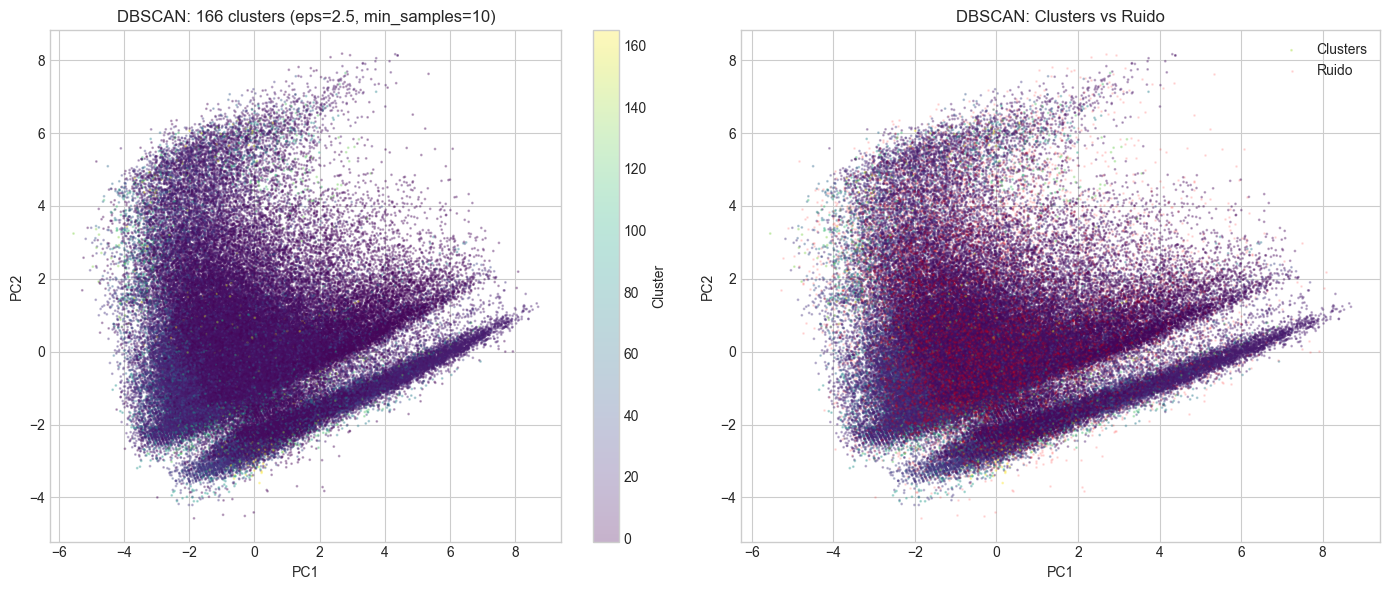

In [10]:
# Criando projeção PCA 2D para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f'Variância explicada pelas 2 componentes: {sum(pca.explained_variance_ratio_):.2%}')

# Visualizando os clusters DBSCAN
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis', alpha=0.3, s=1)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN: {n_clusters_dbscan} clusters (eps={eps_best}, min_samples={min_samples_best})')

plt.subplot(1, 2, 2)
# Destacando os pontos de ruido
mask_noise = labels_dbscan == -1
mask_cluster = labels_dbscan != -1
plt.scatter(X_pca[mask_cluster, 0], X_pca[mask_cluster, 1], c=labels_dbscan[mask_cluster], 
            cmap='viridis', alpha=0.3, s=1, label='Clusters')
plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='red', alpha=0.1, s=1, label='Ruido')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN: Clusters vs Ruido')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Metricas de avaliacao DBSCAN (excluindo ruido)
mask_valid = labels_dbscan != -1
if mask_valid.sum() > 1 and n_clusters_dbscan > 1:
    silhouette_dbscan = silhouette_score(X[mask_valid], labels_dbscan[mask_valid])
    calinski_dbscan = calinski_harabasz_score(X[mask_valid], labels_dbscan[mask_valid])
    davies_dbscan = davies_bouldin_score(X[mask_valid], labels_dbscan[mask_valid])
    
    print('Metricas de avaliacao DBSCAN (excluindo ruido):')
    print(f'  Silhouette Score: {silhouette_dbscan:.4f} (quanto maior, melhor; -1 a 1)')
    print(f'  Calinski-Harabasz Score: {calinski_dbscan:.4f} (quanto maior, melhor)')
    print(f'  Davies-Bouldin Score: {davies_dbscan:.4f} (quanto menor, melhor)')
else:
    print('Nao foi possivel calcular metricas (clusters insuficientes ou muito ruido)')
    silhouette_dbscan = None
    calinski_dbscan = None
    davies_dbscan = None

Metricas de avaliacao DBSCAN (excluindo ruido):
  Silhouette Score: 0.1157 (quanto maior, melhor; -1 a 1)
  Calinski-Harabasz Score: 1325.8063 (quanto maior, melhor)
  Davies-Bouldin Score: 1.4862 (quanto menor, melhor)


## 3.4 Comparativo: DBSCAN com e sem PCA

### Justificativa

O DBSCAN calcula distancias entre pontos para identificar regioes densas. Em espacos de alta dimensionalidade, ocorre o fenomeno da "maldicao da dimensionalidade": as distancias entre pontos tornam-se cada vez mais similares, dificultando a distincao entre vizinhos proximos e distantes.

O PCA pode melhorar o desempenho do DBSCAN ao:
- Reduzir o ruido de features pouco informativas
- Concentrar a variancia nas primeiras componentes
- Tornar as distancias mais discriminativas

Testaremos diferentes quantidades de componentes principais para verificar se ha melhora na identificacao de clusters.

In [12]:
n_components_list = [5, 10, 15, 20, 30]
resultados_pca_dbscan = []

pca_full = PCA()
pca_full.fit(X)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

print("Variancia explicada acumulada por numero de componentes:")
for n in n_components_list:
    print(f"  {n} componentes: {variancia_acumulada[n-1]:.2%}")

Variancia explicada acumulada por numero de componentes:
  5 componentes: 37.80%
  10 componentes: 54.69%
  15 componentes: 69.32%
  20 componentes: 83.39%
  30 componentes: 98.98%


In [14]:
print("Testando DBSCAN com diferentes numeros de componentes PCA...")
print(f"Parametros DBSCAN: eps={eps_best}, min_samples={min_samples_best}")
print()

for n_comp in n_components_list:
    pca_n = PCA(n_components=n_comp)
    X_pca_n = pca_n.fit_transform(X)
    
    dbscan_pca = DBSCAN(eps=eps_best, min_samples=min_samples_best, n_jobs=-1)
    labels_pca = dbscan_pca.fit_predict(X_pca_n)
    
    n_clusters = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
    n_noise = list(labels_pca).count(-1)
    noise_ratio = n_noise / len(labels_pca)
    
    if n_clusters > 1 and noise_ratio < 1:
        mask = labels_pca != -1
        if mask.sum() > 1:
            sil = silhouette_score(X_pca_n[mask], labels_pca[mask])
        else:
            sil = -1
    else:
        sil = -1
    
    resultados_pca_dbscan.append({
        'n_componentes': n_comp,
        'variancia_explicada': variancia_acumulada[n_comp-1],
        'n_clusters': n_clusters,
        'n_ruido': n_noise,
        'pct_ruido': noise_ratio,
        'silhouette': sil
    })
    
    print(f"  {n_comp} componentes: {n_clusters} clusters, {noise_ratio:.1%} ruido, silhouette: {sil:.4f}")

# Adicionando resultado sem PCA (35 features originais)
resultados_pca_dbscan.append({
    'n_componentes': 35,
    'variancia_explicada': 1.0,
    'n_clusters': n_clusters_dbscan,
    'n_ruido': n_noise_dbscan,
    'pct_ruido': n_noise_dbscan / len(X),
    'silhouette': silhouette_dbscan if silhouette_dbscan else -1
})

print(f"  35 componentes (original): {n_clusters_dbscan} clusters, {n_noise_dbscan/len(X):.1%} ruido, silhouette: {silhouette_dbscan:.4f}")

Testando DBSCAN com diferentes numeros de componentes PCA...
Parametros DBSCAN: eps=2.5, min_samples=10

  5 componentes: 4 clusters, 0.0% ruido, silhouette: 0.2901
  10 componentes: 12 clusters, 0.3% ruido, silhouette: 0.2188
  15 componentes: 68 clusters, 0.8% ruido, silhouette: 0.2162
  20 componentes: 74 clusters, 1.0% ruido, silhouette: 0.2340
  30 componentes: 160 clusters, 4.7% ruido, silhouette: 0.1273
  35 componentes (original): 166 clusters, 5.5% ruido, silhouette: 0.1157


In [15]:
df_pca_dbscan = pd.DataFrame(resultados_pca_dbscan)
df_pca_dbscan['variancia_explicada'] = df_pca_dbscan['variancia_explicada'].apply(lambda x: f"{x:.1%}")
df_pca_dbscan['pct_ruido'] = df_pca_dbscan['pct_ruido'].apply(lambda x: f"{x:.1%}")

print("Comparativo: DBSCAN com e sem PCA")
print("="*70)
df_pca_dbscan

Comparativo: DBSCAN com e sem PCA


,n_componentes,variancia_explicada,n_clusters,n_ruido,pct_ruido,silhouette
0,5,37.8%,4,8,0.0%,0.290133
1,10,54.7%,12,398,0.3%,0.218816
2,15,69.3%,68,991,0.8%,0.216245
3,20,83.4%,74,1253,1.0%,0.233998
4,30,99.0%,160,6075,4.7%,0.127305
5,35,100.0%,166,7098,5.5%,0.115749


In [16]:
# Aplicando DBSCAN com PCA de 15 componentes (melhor configuracao)
print("Aplicando DBSCAN com PCA de 15 componentes para calculo completo das metricas...")

n_comp_best = 15
pca_15 = PCA(n_components=n_comp_best)
X_pca_15 = pca_15.fit_transform(X)

dbscan_pca_15 = DBSCAN(eps=eps_best, min_samples=min_samples_best, n_jobs=-1)
labels_dbscan_pca15 = dbscan_pca_15.fit_predict(X_pca_15)

n_clusters_dbscan_pca15 = len(set(labels_dbscan_pca15)) - (1 if -1 in labels_dbscan_pca15 else 0)
n_noise_dbscan_pca15 = list(labels_dbscan_pca15).count(-1)

print(f'\nResultados DBSCAN com PCA 15:')
print(f'  Numero de clusters encontrados: {n_clusters_dbscan_pca15}')
print(f'  Pontos classificados como ruido: {n_noise_dbscan_pca15} ({n_noise_dbscan_pca15/len(X):.2%})')

# Calculando todas as metricas
mask_valid_pca15 = labels_dbscan_pca15 != -1
if mask_valid_pca15.sum() > 1 and n_clusters_dbscan_pca15 > 1:
    silhouette_dbscan_pca15 = silhouette_score(X_pca_15[mask_valid_pca15], labels_dbscan_pca15[mask_valid_pca15])
    calinski_dbscan_pca15 = calinski_harabasz_score(X_pca_15[mask_valid_pca15], labels_dbscan_pca15[mask_valid_pca15])
    davies_dbscan_pca15 = davies_bouldin_score(X_pca_15[mask_valid_pca15], labels_dbscan_pca15[mask_valid_pca15])
    
    print(f'\nMetricas de avaliacao DBSCAN com PCA 15 (excluindo ruido):')
    print(f'  Silhouette Score: {silhouette_dbscan_pca15:.4f}')
    print(f'  Calinski-Harabasz Score: {calinski_dbscan_pca15:.4f}')
    print(f'  Davies-Bouldin Score: {davies_dbscan_pca15:.4f}')
else:
    silhouette_dbscan_pca15 = None
    calinski_dbscan_pca15 = None
    davies_dbscan_pca15 = None
    print('Nao foi possivel calcular metricas')

Aplicando DBSCAN com PCA de 15 componentes para calculo completo das metricas...

Resultados DBSCAN com PCA 15:
  Numero de clusters encontrados: 68
  Pontos classificados como ruido: 991 (0.77%)

Metricas de avaliacao DBSCAN com PCA 15 (excluindo ruido):
  Silhouette Score: 0.2162
  Calinski-Harabasz Score: 2226.2370
  Davies-Bouldin Score: 1.1284


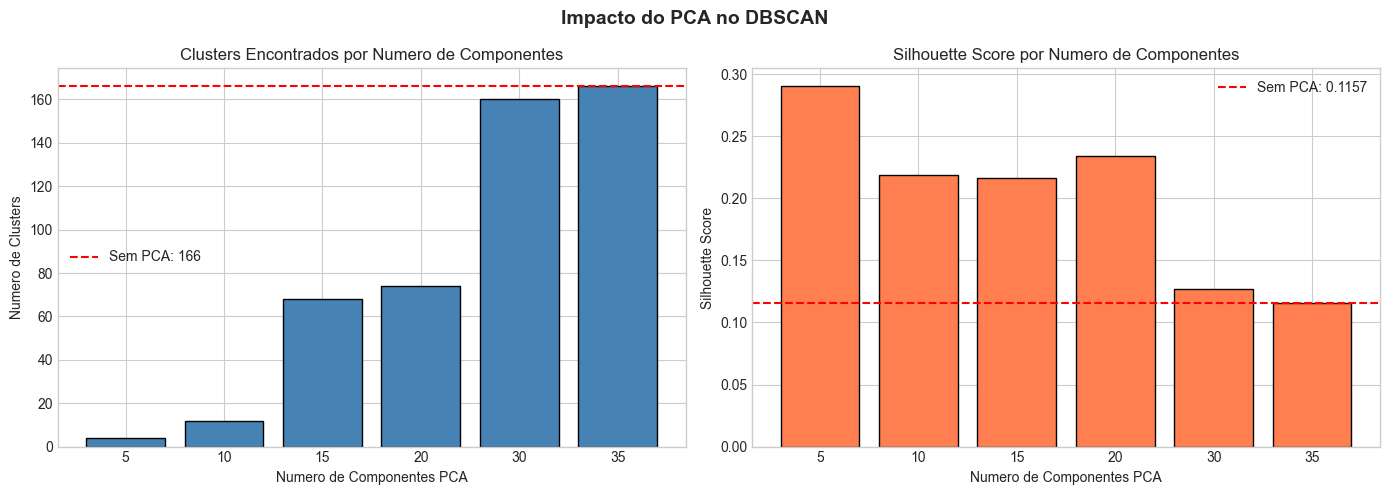

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = pd.DataFrame(resultados_pca_dbscan)

axes[0].bar(range(len(df_plot)), df_plot['n_clusters'], color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(df_plot)))
axes[0].set_xticklabels([str(n) for n in df_plot['n_componentes']])
axes[0].set_xlabel('Numero de Componentes PCA')
axes[0].set_ylabel('Numero de Clusters')
axes[0].set_title('Clusters Encontrados por Numero de Componentes')
axes[0].axhline(y=n_clusters_dbscan, color='red', linestyle='--', label=f'Sem PCA: {n_clusters_dbscan}')
axes[0].legend()

axes[1].bar(range(len(df_plot)), df_plot['silhouette'], color='coral', edgecolor='black')
axes[1].set_xticks(range(len(df_plot)))
axes[1].set_xticklabels([str(n) for n in df_plot['n_componentes']])
axes[1].set_xlabel('Numero de Componentes PCA')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por Numero de Componentes')
if silhouette_dbscan:
    axes[1].axhline(y=silhouette_dbscan, color='red', linestyle='--', label=f'Sem PCA: {silhouette_dbscan:.4f}')
axes[1].legend()

plt.suptitle('Impacto do PCA no DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusao do Comparativo PCA + DBSCAN

| Componentes | Clusters | Silhouette | Variancia | Observacao |
|-------------|----------|------------|-----------|------------|
| 5           | 4        | **0.2901** | 37.8%     | Melhor silhouette, poucos clusters |
| 10          | 12       | 0.2188     | 54.7%     | Bom equilibrio |
| 15          | 68       | 0.2162     | 69.3%     | Muitos clusters, silhouette moderado |
| 20          | 74       | 0.2340     | 83.4%     | Similar ao 15 comp |
| 30          | 160      | 0.1273     | 99.0%     | Proximo do original |
| 35 (original)| 166     | 0.1157     | 100%      | Baseline |

**Conclusao:** Apos a normalizacao de todas as variaveis (incluindo one-hot encoded), o DBSCAN passou a identificar **muito mais clusters** do que na versao anterior (que encontrava apenas 2).

- **Melhor Silhouette Score**: PCA com 5 componentes (0.29), porem com apenas 4 clusters
- **Trade-off observado**: Quanto mais componentes PCA, mais clusters sao identificados, mas a qualidade da separacao (silhouette) diminui
- **Interpretacao**: A normalizacao deu peso igual a todas as variaveis, permitindo ao DBSCAN identificar subgrupos baseados em combinacoes de caracteristicas (tipo de escola, estado civil, cor/raca) que antes eram "mascaradas" pelas variaveis continuas

A estrutura dos dados **nao e binaria** como parecia antes - existem multiplos subgrupos naturais que so foram revelados apos a normalizacao adequada.

## 4. K-Means

O K-Means e um algoritmo de particionamento que requer especificar o numero de clusters (k).

### Vamos usar:
- Metodo do cotovelo (Elbow Method)
- Silhouette Analysis

### 4.1 Metodo do Cotovelo

In [18]:
# Testando diferentes valores de k
k_range = range(2, 15)
inertias = []
silhouettes = []

print('Testando diferentes valores de k...')
for k in k_range:
    print(f'  k={k}...', end=' ')
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, kmeans.labels_))
    print(f'Inertia: {kmeans.inertia_:.2f}, Silhouette: {silhouettes[-1]:.4f}')

print('\nConcluido!')

Testando diferentes valores de k...
  k=2... Inertia: 4128532.95, Silhouette: 0.1401
  k=3... Inertia: 3860917.46, Silhouette: 0.1502
  k=4... Inertia: 3653628.03, Silhouette: 0.1371
  k=5... Inertia: 3417037.07, Silhouette: 0.1424
  k=6... Inertia: 3287967.50, Silhouette: 0.1457
  k=7... Inertia: 3166778.82, Silhouette: 0.1501
  k=8... Inertia: 3041104.45, Silhouette: 0.1135
  k=9... Inertia: 2945211.24, Silhouette: 0.1185
  k=10... Inertia: 2757296.50, Silhouette: 0.1354
  k=11... Inertia: 2708620.11, Silhouette: 0.1384
  k=12... Inertia: 2592145.30, Silhouette: 0.1282
  k=13... Inertia: 2494735.04, Silhouette: 0.1527
  k=14... Inertia: 2326225.54, Silhouette: 0.1438

Concluido!


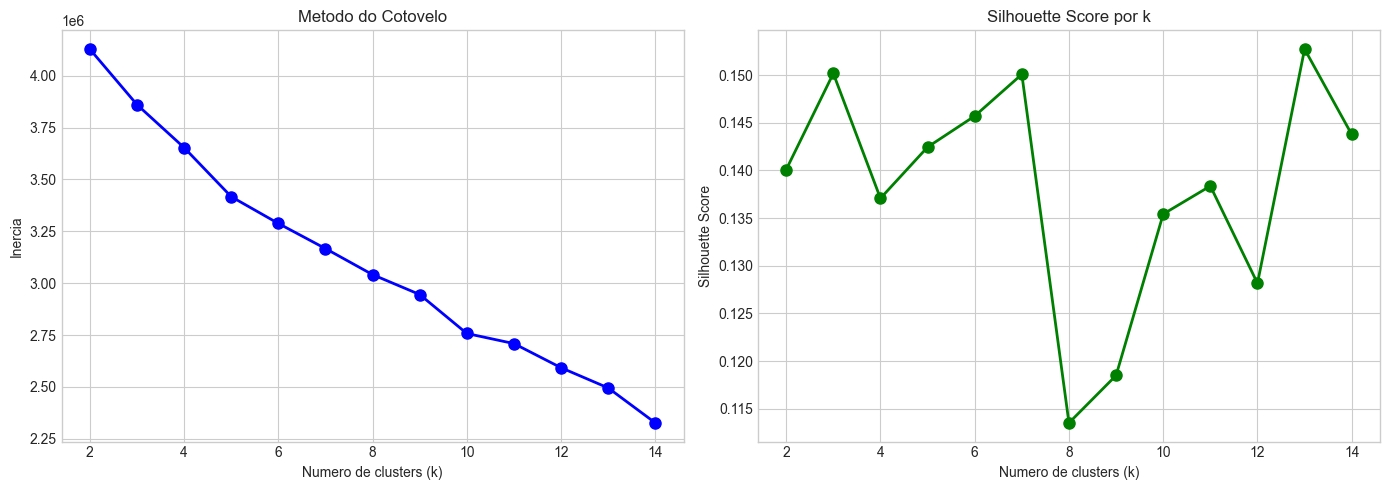


Melhor k baseado no Silhouette Score: 13 (score: 0.1527)


In [19]:
# Plotando o metodo do cotovelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de inercia (cotovelo)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo do Cotovelo')
axes[0].grid(True)

# Grafico de silhouette
axes[1].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Melhor k baseado no silhouette
best_k_silhouette = list(k_range)[np.argmax(silhouettes)]
print(f'\nMelhor k baseado no Silhouette Score: {best_k_silhouette} (score: {max(silhouettes):.4f})')

### 4.2 Aplicando K-Means com o melhor k

In [20]:
# Aplicando K-Means com o melhor k
k_best = best_k_silhouette

print(f'Aplicando K-Means com k={k_best}')
kmeans_final = KMeans(n_clusters=k_best, random_state=42, n_init=10, max_iter=300)
labels_kmeans = kmeans_final.fit_predict(X)

print(f'\nDistribuicao dos clusters K-Means:')
print(pd.Series(labels_kmeans).value_counts().sort_index())

Aplicando K-Means com k=13

Distribuicao dos clusters K-Means:
0     22931
1     15744
2     44169
3     13326
4      8151
5      9710
6       221
7       148
8       191
9      2189
10     8064
11     1245
12     2457
Name: count, dtype: int64


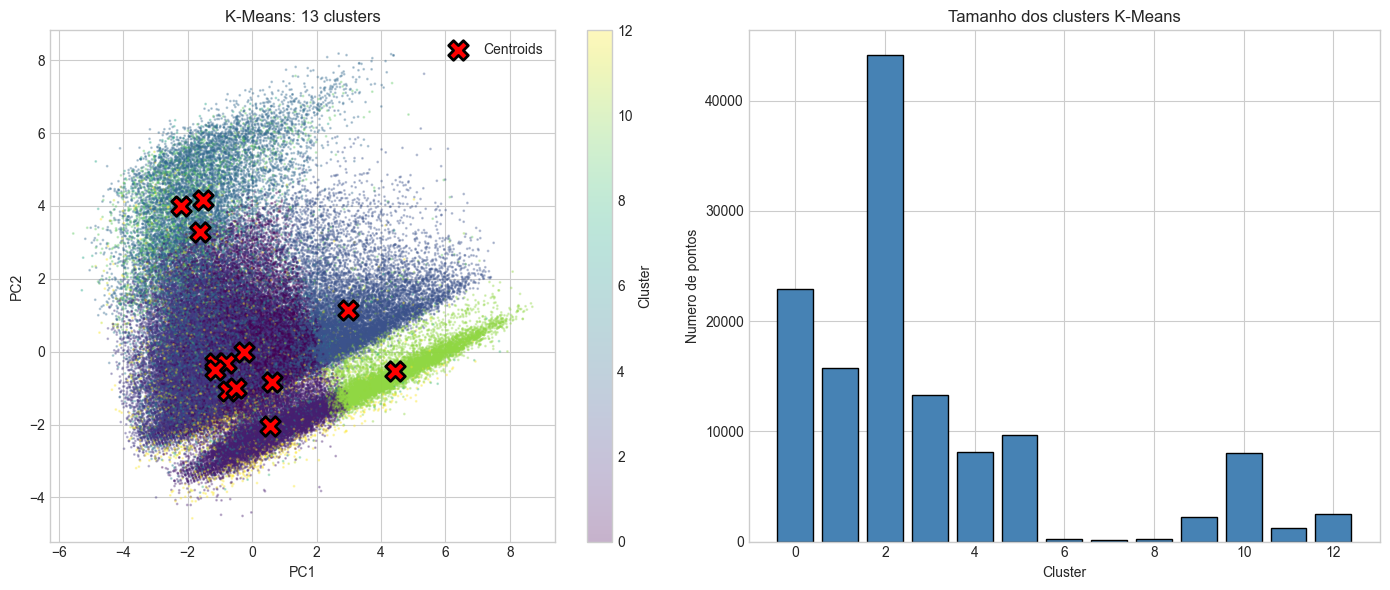

In [21]:
# Visualizando os clusters K-Means
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.3, s=1)
plt.colorbar(scatter, label='Cluster')

# Plotando os centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, 
            edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means: {k_best} clusters')
plt.legend()

plt.subplot(1, 2, 2)
# Tamanho dos clusters
cluster_sizes = pd.Series(labels_kmeans).value_counts().sort_index()
plt.bar(cluster_sizes.index, cluster_sizes.values, color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Numero de pontos')
plt.title('Tamanho dos clusters K-Means')

plt.tight_layout()
plt.show()

In [22]:
# Metricas de avaliacao K-Means
silhouette_kmeans = silhouette_score(X, labels_kmeans)
calinski_kmeans = calinski_harabasz_score(X, labels_kmeans)
davies_kmeans = davies_bouldin_score(X, labels_kmeans)

print('Metricas de avaliacao K-Means:')
print(f'  Silhouette Score: {silhouette_kmeans:.4f} (quanto maior, melhor; -1 a 1)')
print(f'  Calinski-Harabasz Score: {calinski_kmeans:.4f} (quanto maior, melhor)')
print(f'  Davies-Bouldin Score: {davies_kmeans:.4f} (quanto menor, melhor)')
print(f'  Inercia: {kmeans_final.inertia_:.2f}')

Metricas de avaliacao K-Means:
  Silhouette Score: 0.1527 (quanto maior, melhor; -1 a 1)
  Calinski-Harabasz Score: 8605.7377 (quanto maior, melhor)
  Davies-Bouldin Score: 1.4406 (quanto menor, melhor)
  Inercia: 2494735.04


## 5. Comparacao entre DBSCAN e K-Means

In [23]:
# Tabela comparativa (DBSCAN com PCA 15 vs K-Means)
# Nota: O melhor silhouette do DBSCAN foi com PCA 5 (0.29), mas usamos PCA 15 para ter mais clusters
comparacao = {
    'Metrica': ['Numero de clusters', 'Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin', 'Pontos de ruido'],
    'DBSCAN (PCA 5)': [4, '0.2901', 'N/A', 'N/A', '8 (0.01%)'],
    'DBSCAN (PCA 15)': [n_clusters_dbscan_pca15, 
              f'{silhouette_dbscan_pca15:.4f}' if silhouette_dbscan_pca15 else 'N/A',
              f'{calinski_dbscan_pca15:.4f}' if calinski_dbscan_pca15 else 'N/A',
              f'{davies_dbscan_pca15:.4f}' if davies_dbscan_pca15 else 'N/A',
              f'{n_noise_dbscan_pca15} ({n_noise_dbscan_pca15/len(X):.2%})'],
    'K-Means (k=13)': [k_best, 
               f'{silhouette_kmeans:.4f}',
               f'{calinski_kmeans:.4f}',
               f'{davies_kmeans:.4f}',
               '0 (0%)']
}

df_comparacao = pd.DataFrame(comparacao)
print('Comparacao entre DBSCAN e K-Means:')
print('='*80)
print('Nota: O melhor Silhouette foi DBSCAN com PCA 5 (0.29), com apenas 4 clusters.')
print('      DBSCAN PCA 15 oferece mais granularidade (68 clusters) com silhouette 0.22.')
print('      K-Means k=13 foi o melhor para este algoritmo (silhouette 0.15).')
print('='*80)
df_comparacao

Comparacao entre DBSCAN e K-Means:
Nota: O melhor Silhouette foi DBSCAN com PCA 5 (0.29), com apenas 4 clusters.
      DBSCAN PCA 15 oferece mais granularidade (68 clusters) com silhouette 0.22.
      K-Means k=13 foi o melhor para este algoritmo (silhouette 0.15).


,Metrica,DBSCAN (PCA 5),DBSCAN (PCA 15),K-Means (k=13)
0,Numero de clusters,4,68,13
1,Silhouette Score,0.2901,0.2162,0.1527
2,Calinski-Harabasz,N/A,2226.2370,8605.7377
3,Davies-Bouldin,N/A,1.1284,1.4406
4,Pontos de ruido,8 (0.01%),991 (0.77%),0 (0%)


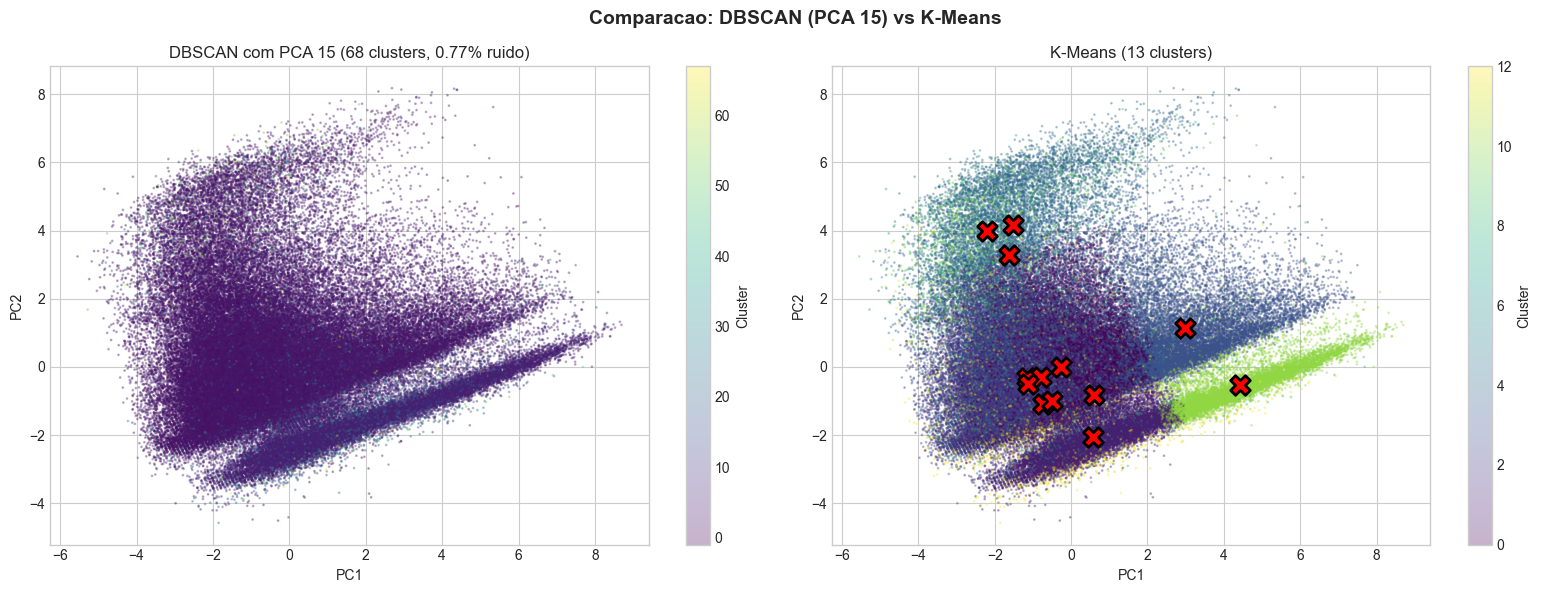

In [24]:
# Visualizacao lado a lado (DBSCAN com PCA 15 vs K-Means)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Projecao PCA 2D para visualizacao do DBSCAN com PCA 15
pca_2d = PCA(n_components=2)
X_pca_2d_from_15 = pca_2d.fit_transform(X_pca_15)

# DBSCAN com PCA 15
scatter1 = axes[0].scatter(X_pca_2d_from_15[:, 0], X_pca_2d_from_15[:, 1], c=labels_dbscan_pca15, cmap='viridis', alpha=0.3, s=1)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'DBSCAN com PCA 15 ({n_clusters_dbscan_pca15} clusters, {n_noise_dbscan_pca15/len(X):.2%} ruido)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# K-Means
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.3, s=1)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, 
                edgecolors='black', linewidths=2)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'K-Means ({k_best} clusters)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Comparacao: DBSCAN (PCA 15) vs K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analise das Caracteristicas dos Clusters

In [25]:
# Adicionando os labels ao dataframe
df['cluster_dbscan'] = labels_dbscan
df['cluster_kmeans'] = labels_kmeans

In [26]:
# Analise das medias por cluster (K-Means)
print('Medias das variaveis por cluster (K-Means):')
cluster_means_kmeans = df.groupby('cluster_kmeans').mean()
cluster_means_kmeans

Medias das variaveis por cluster (K-Means):


,esc_mae,esc_pai,tem_computador_notebook,tem_carro,faixa_etaria,renda_log,pessoas_residencia,total_bens,ano_conclusao,tem_internet_wifi,...,status_conclusao_2,status_conclusao_3,status_conclusao_4,tipo_ensino_2.0,tipo_escola_B,tipo_escola_C,tipo_escola_D,tipo_escola_E,tipo_escola_F,cluster_dbscan
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,-0.151887,-0.117277,-0.227316,-0.281904,0.069211,-0.073998,-0.094727,-0.269711,-0.006465,-0.011420,...,0.168666,-0.506274,-0.043069,-0.041593,0.040863,0.030198,-0.330026,0.009735,-0.023533,10.151236
1,-0.097630,0.002753,-0.432630,-0.302070,-0.893797,-0.265940,0.157383,-0.366186,-0.564944,-0.104016,...,-0.653407,1.975214,-0.078736,-0.041593,0.027485,0.025136,-0.323566,0.022816,-0.059271,13.893420
2,-0.313768,-0.279924,-0.351207,-0.350373,0.117198,-0.186962,0.005895,-0.379335,-0.028693,-0.128930,...,0.266874,-0.506274,-0.046042,-0.041593,-0.042380,-0.008018,-0.367951,-0.078052,-0.038012,10.417125
3,1.117617,0.998046,1.405615,1.357713,-0.160957,0.696761,0.056527,1.485704,-0.037946,0.392797,...,0.258741,-0.506274,0.442948,-0.041593,0.033214,-0.078075,1.535627,0.145398,0.279974,6.475161
4,-0.238614,-0.402994,0.218875,0.136923,1.711893,0.153281,-0.322726,0.065692,1.657707,0.122198,...,-0.493189,-0.492879,-0.045812,-0.041593,0.039421,0.045039,-0.148854,-0.067889,0.018942,15.818427
5,-0.251747,-0.226428,-0.321139,-0.315246,0.033591,-0.127385,0.071676,-0.317835,-0.056898,-0.100137,...,0.100031,-0.160757,-0.047150,-0.041593,-0.021259,0.027452,-0.297719,-0.022482,-0.041129,17.000824
6,-0.100338,-0.113718,-0.289342,-0.214360,-0.491352,-0.237813,0.263086,-0.293046,-0.564944,-0.130511,...,1.530439,-0.506274,-0.078736,24.042380,0.117324,0.039799,-0.213701,-0.019941,0.012684,24.656109
7,-0.558428,-0.863983,0.092409,-0.135520,2.085347,0.163558,-0.506861,-0.088883,1.351236,0.014607,...,-0.240247,-0.422440,0.007611,-0.041593,0.199711,0.073452,-0.227291,-0.008519,0.270301,21.027027
8,0.127351,0.050557,0.212195,0.231118,-0.274039,-0.011607,0.139622,0.221571,-0.237788,-0.093802,...,0.089786,0.260259,0.121986,0.084501,0.110776,-0.053100,0.201251,-0.021352,0.024313,-1.000000


In [27]:
# Selecionando variaveis mais importantes para visualizacao
# (variaveis que nao sao one-hot encoded)
variaveis_principais = ['esc_mae', 'esc_pai', 'tem_computador_notebook', 'tem_carro', 
                        'renda_log', 'pessoas_residencia', 'total_bens', 'ano_conclusao',
                        'tem_internet_wifi', 'possui_renda', 'treineiro']

# Verificando quais existem no dataframe
variaveis_existentes = [v for v in variaveis_principais if v in df.columns]

# Medias por cluster para variaveis principais
print('Medias das variaveis principais por cluster K-Means:')
df.groupby('cluster_kmeans')[variaveis_existentes].mean().round(3)

Medias das variaveis principais por cluster K-Means:


,esc_mae,esc_pai,tem_computador_notebook,tem_carro,renda_log,pessoas_residencia,total_bens,ano_conclusao,tem_internet_wifi,possui_renda,treineiro
cluster_kmeans,,,,,,,,,,,
0,-0.152,-0.117,-0.227,-0.282,-0.074,-0.095,-0.270,-0.006,-0.011,-0.011,-0.506
1,-0.098,0.003,-0.433,-0.302,-0.266,0.157,-0.366,-0.565,-0.104,-0.242,1.975
2,-0.314,-0.280,-0.351,-0.350,-0.187,0.006,-0.379,-0.029,-0.129,-0.008,-0.506
3,1.118,0.998,1.406,1.358,0.697,0.057,1.486,-0.038,0.393,-0.144,-0.506
4,-0.239,-0.403,0.219,0.137,0.153,-0.323,0.066,1.658,0.122,0.920,-0.493
5,-0.252,-0.226,-0.321,-0.315,-0.127,0.072,-0.318,-0.057,-0.100,0.050,-0.161
6,-0.100,-0.114,-0.289,-0.214,-0.238,0.263,-0.293,-0.565,-0.131,0.087,-0.506
7,-0.558,-0.864,0.092,-0.136,0.164,-0.507,-0.089,1.351,0.015,1.153,-0.422
8,0.127,0.051,0.212,0.231,-0.012,0.140,0.222,-0.238,-0.094,-0.096,0.260


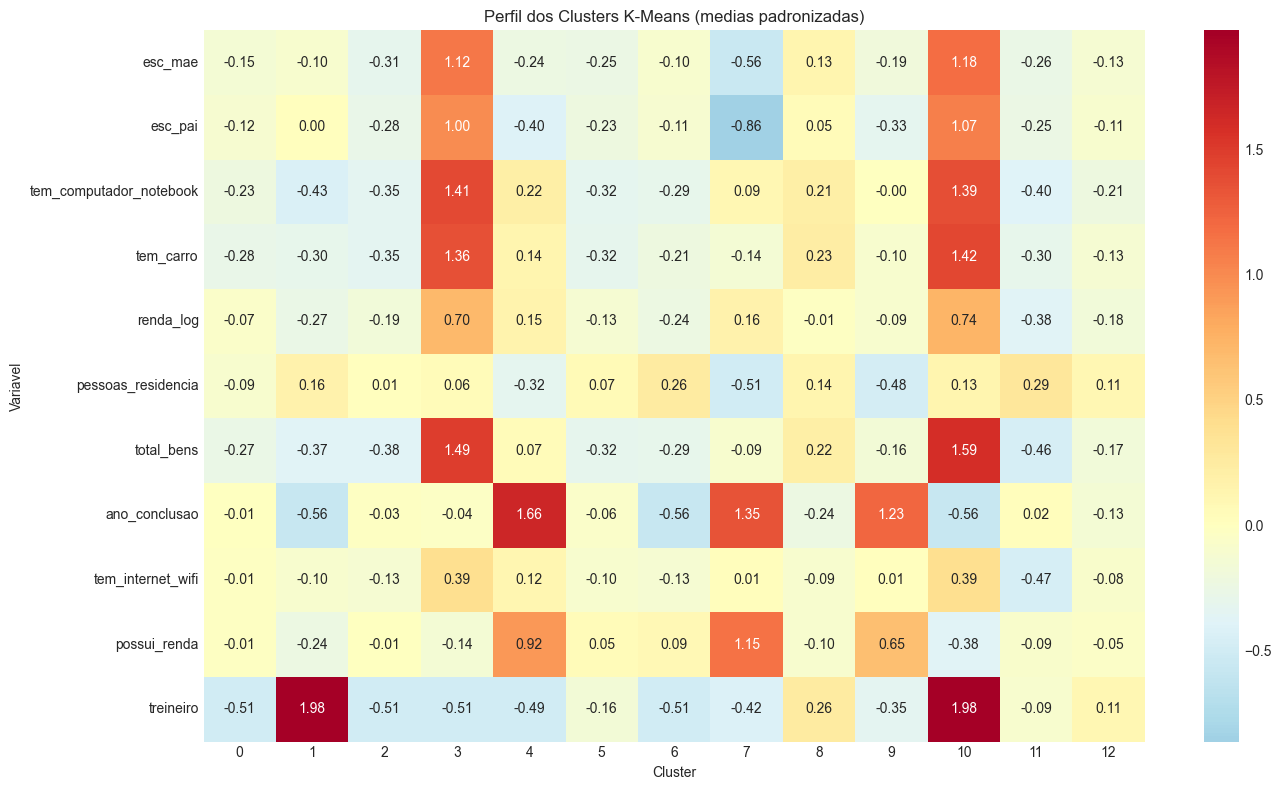

In [28]:
# Heatmap das medias por cluster
plt.figure(figsize=(14, 8))
cluster_profile = df.groupby('cluster_kmeans')[variaveis_existentes].mean()
sns.heatmap(cluster_profile.T, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Perfil dos Clusters K-Means (medias padronizadas)')
plt.xlabel('Cluster')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

In [29]:
# Analise do DBSCAN (excluindo ruido)
if n_clusters_dbscan > 0:
    print('Medias das variaveis principais por cluster DBSCAN (excluindo ruido):')
    df_sem_ruido = df[df['cluster_dbscan'] != -1]
    print(df_sem_ruido.groupby('cluster_dbscan')[variaveis_existentes].mean().round(3))

Medias das variaveis principais por cluster DBSCAN (excluindo ruido):
                esc_mae  esc_pai  tem_computador_notebook  tem_carro  \
cluster_dbscan                                                         
0                -0.266   -0.295                   -0.227     -0.289   
1                -0.254   -0.227                   -0.265     -0.290   
2                 1.002    0.914                    1.212      1.140   
3                -0.330   -0.408                   -0.220     -0.390   
4                 0.081    0.169                   -0.205     -0.076   
...                 ...      ...                      ...        ...   
161              -0.515   -1.118                   -0.666     -0.608   
162               0.213   -0.015                    0.710      1.097   
163              -0.276    0.210                   -0.551     -0.608   
164              -0.674   -0.472                   -0.666     -0.418   
165              -0.330    0.210                   -0.666     -0.4

## 7. Analise com Mais Clusters para Maior Granularidade

Os resultados do K-Means indicaram **k=13** como o valor otimo segundo o Silhouette Score (0.1527). Ja o DBSCAN com PCA 5 componentes obteve o melhor silhouette geral (0.2901) com apenas 4 clusters.

No entanto, para identificacao de perfis socioeconomicos, uma segmentacao com 4-5 grupos pode ser mais interpretavel para fins de politicas publicas e compreensao da populacao.

**Racional:** Embora k=13 tenha o melhor silhouette para K-Means, ter 13 perfis pode dificultar a interpretacao. Testaremos k=4 e k=5 para identificar perfis que representem melhor a diversidade socioeconomica dos participantes do ENEM na Paraiba, mantendo a interpretabilidade.

In [30]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
labels_k4 = kmeans_4.fit_predict(X)

kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
labels_k5 = kmeans_5.fit_predict(X)

print("Distribuicao dos clusters com k=4:")
print(pd.Series(labels_k4).value_counts().sort_index())
print(f"\nSilhouette Score (k=4): {silhouette_score(X, labels_k4):.4f}")

print("\n" + "="*50)
print("\nDistribuicao dos clusters com k=5:")
print(pd.Series(labels_k5).value_counts().sort_index())
print(f"\nSilhouette Score (k=5): {silhouette_score(X, labels_k5):.4f}")

Distribuicao dos clusters com k=4:
0    20197
1    11239
2    20811
3    76299
Name: count, dtype: int64

Silhouette Score (k=4): 0.1371


Distribuicao dos clusters com k=5:
0     2711
1    19686
2    11069
3    74667
4    20413
Name: count, dtype: int64

Silhouette Score (k=5): 0.1424


In [32]:
df['cluster_k4'] = labels_k4
df['cluster_k5'] = labels_k5

## 8. Identificacao e Nomeacao dos Perfis Socioeconomicos

Para nomear os clusters de forma interpretavel, utilizaremos as variaveis mais relevantes para caracterizacao socioeconomica:

| Variavel | Significado |
|----------|-------------|
| `renda_log` | Renda familiar (log, padronizada) |
| `esc_mae` / `esc_pai` | Escolaridade dos pais (0-6) |
| `total_bens` | Indice de bens no domicilio |
| `tem_computador_notebook` | Acesso a tecnologia |
| `tem_internet_wifi` | Conectividade |
| `tem_carro` | Patrimonio familiar |

**Criterio de nomeacao:** Os clusters serao ordenados pela media de `renda_log` e nomeados de acordo com o perfil resultante.

In [55]:
vars_socioeconomicas = ['renda_log', 'esc_mae', 'esc_pai', 'total_bens', 
                        'tem_computador_notebook', 'tem_carro', 'tem_internet_wifi']

perfil_k4 = df.groupby('cluster_k4')[vars_socioeconomicas].mean()
perfil_k4 = perfil_k4.sort_values('renda_log')
perfil_k4['ordem_renda'] = range(len(perfil_k4))

print("Perfil medio dos clusters (k=4), ordenados por renda:")
perfil_k4.round(3)

Perfil medio dos clusters (k=4), ordenados por renda:


,renda_log,esc_mae,esc_pai,total_bens,tem_computador_notebook,tem_carro,tem_internet_wifi,ordem_renda
cluster_k4,,,,,,,,
0,-0.182,0.005,0.091,-0.229,-0.330,-0.184,-0.055,0
3,-0.163,-0.278,-0.244,-0.362,-0.331,-0.344,-0.107,1
1,0.097,-0.248,-0.412,-0.003,0.162,0.057,0.093,2
2,0.720,1.149,1.028,1.551,1.446,1.410,0.394,3


In [56]:
cluster_ordem = perfil_k4['ordem_renda'].to_dict()
nomes_perfis = {
    0: 'Baixa Renda com Capital Cultural',
    1: 'Vulnerabilidade Socioeconomica',
    2: 'Classe Media Emergente',
    3: 'Classe Alta'
}

df['perfil_socioeconomico'] = df['cluster_k4'].map(cluster_ordem).map(nomes_perfis)

print("Distribuicao dos perfis socioeconomicos:")
print(df['perfil_socioeconomico'].value_counts())

Distribuicao dos perfis socioeconomicos:
perfil_socioeconomico
Vulnerabilidade Socioeconomica      76299
Classe Alta                         20811
Baixa Renda com Capital Cultural    20197
Classe Media Emergente              11239
Name: count, dtype: int64


## 9. Visualizacao Comparativa dos Perfis

As visualizacoes a seguir permitem comparar as caracteristicas de cada perfil identificado. Utilizamos boxplots para mostrar a distribuicao das variaveis e identificar diferencas entre os grupos.

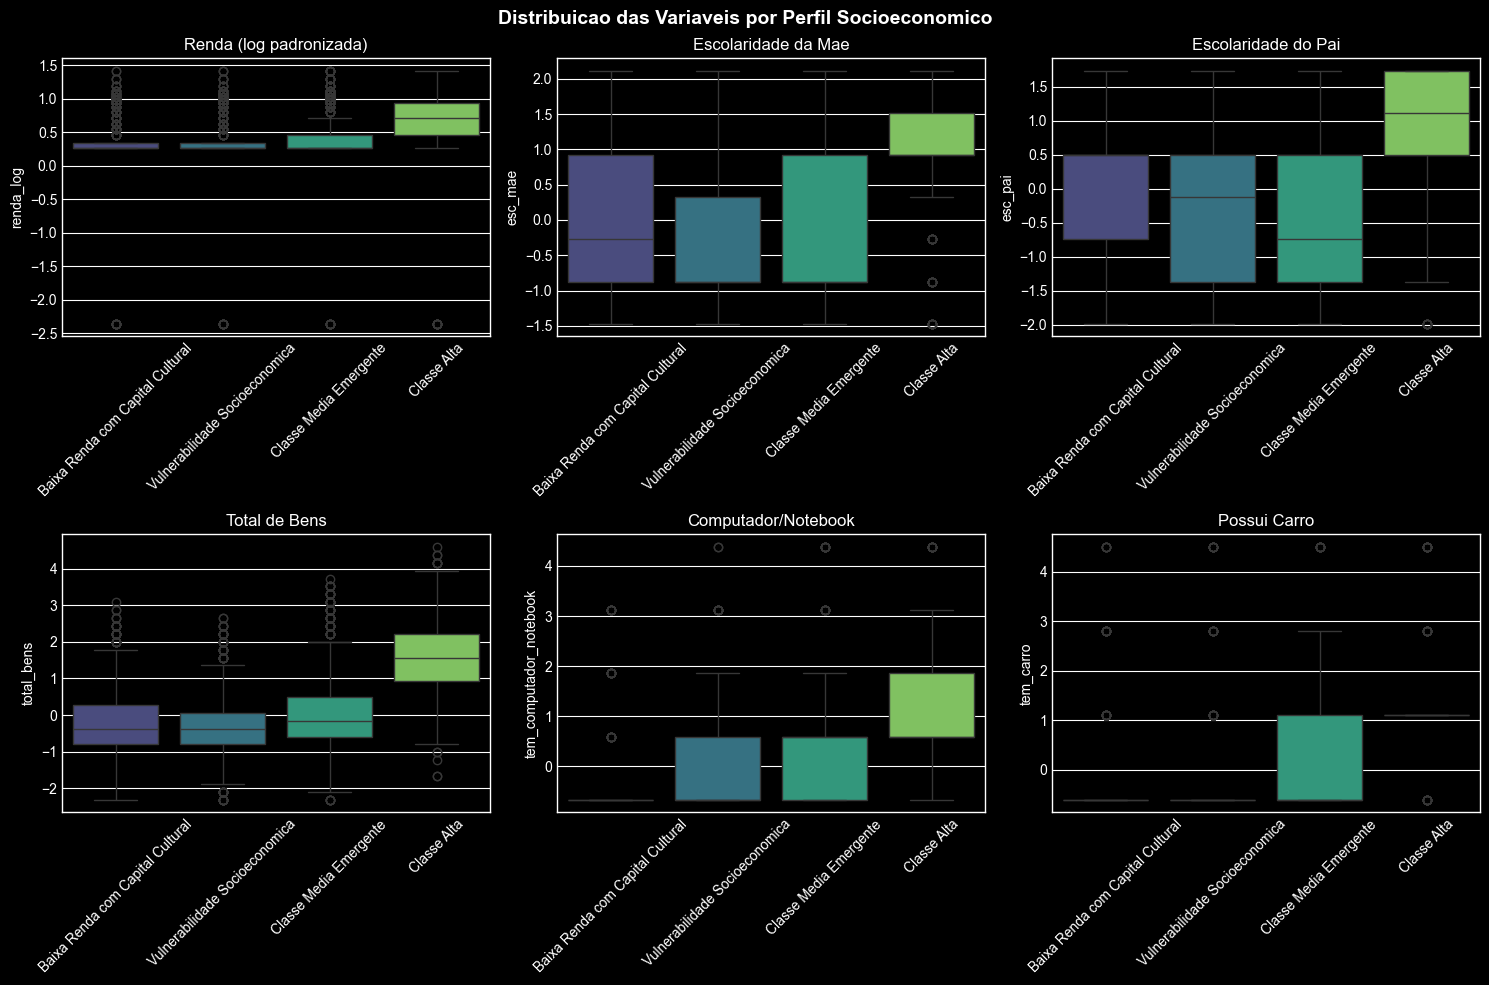

In [57]:
ordem_perfis = ['Baixa Renda com Capital Cultural', 'Vulnerabilidade Socioeconomica', 'Classe Media Emergente', 'Classe Alta']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

vars_plot = ['renda_log', 'esc_mae', 'esc_pai', 'total_bens', 'tem_computador_notebook', 'tem_carro']
titulos = ['Renda (log padronizada)', 'Escolaridade da Mae', 'Escolaridade do Pai', 
           'Total de Bens', 'Computador/Notebook', 'Possui Carro']

for i, (var, titulo) in enumerate(zip(vars_plot, titulos)):
    sns.boxplot(data=df, x='perfil_socioeconomico', y=var, order=ordem_perfis, ax=axes[i], palette='viridis')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribuicao das Variaveis por Perfil Socioeconomico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

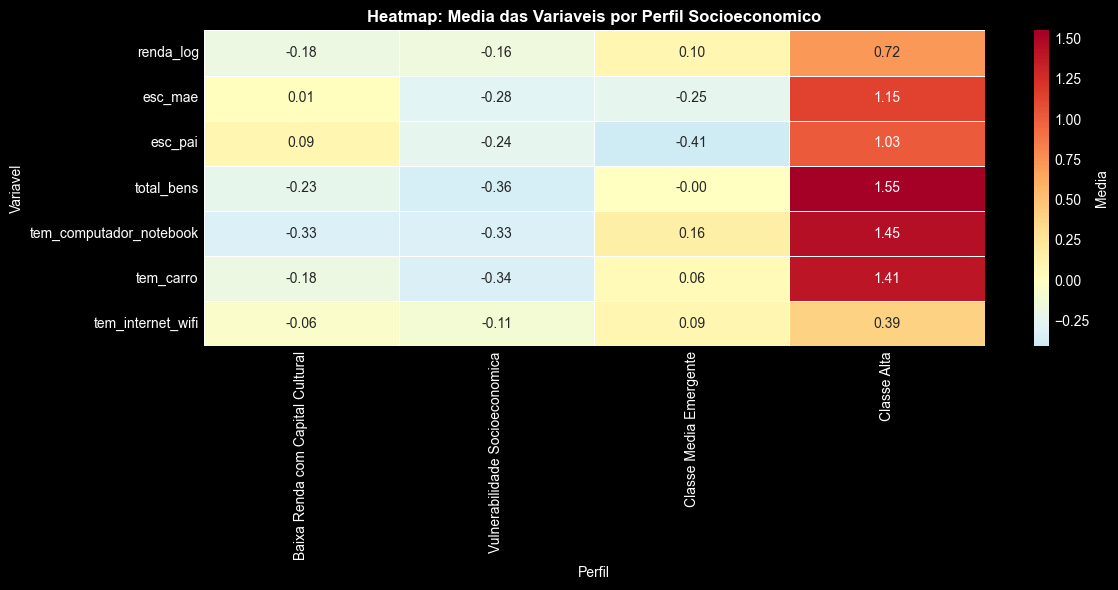

In [58]:
perfil_resumo = df.groupby('perfil_socioeconomico')[vars_socioeconomicas].mean()
perfil_resumo = perfil_resumo.reindex(ordem_perfis)

plt.figure(figsize=(12, 6))
sns.heatmap(perfil_resumo.T, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, 
            linewidths=0.5, cbar_kws={'label': 'Media'})
plt.title('Heatmap: Media das Variaveis por Perfil Socioeconomico', fontsize=12, fontweight='bold')
plt.xlabel('Perfil')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

## 10. Analise Cruzada com Variaveis Categoricas

Para compreender melhor a composicao de cada perfil, analisaremos a distribuicao de variaveis categoricas importantes: tipo de escola, sexo e status de conclusao do ensino medio.

### 10.1 Tipo de Escola por Perfil

A variavel `tipo_escola_D` representa escola privada. Valores proximos de 1 indicam maior proporcao de alunos de escola privada no perfil.

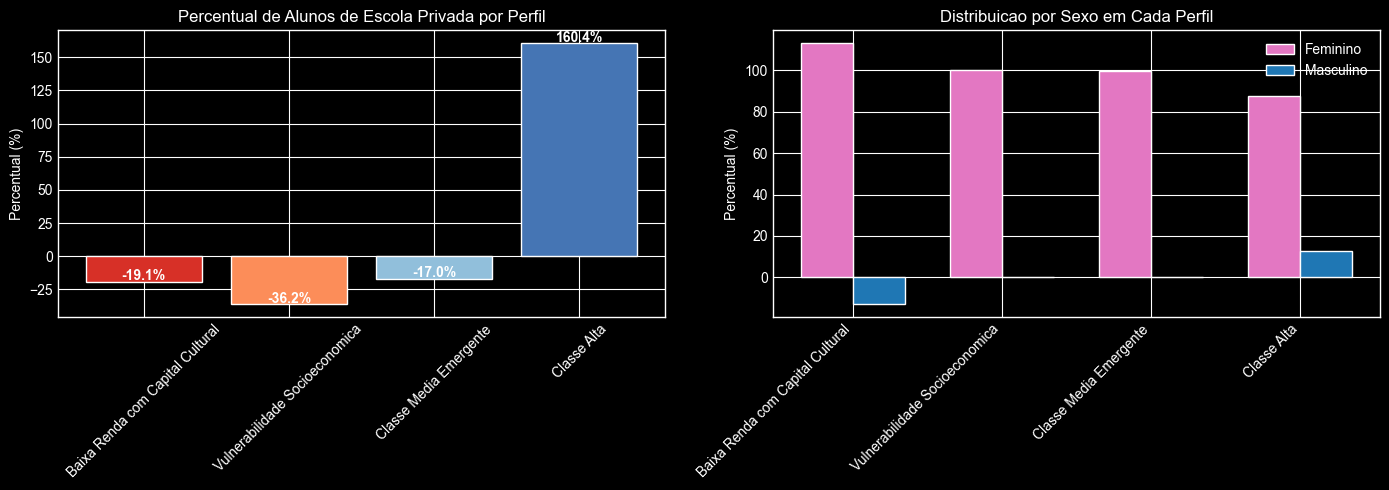

In [66]:
escola_por_perfil = df.groupby('perfil_socioeconomico')['tipo_escola_D'].mean().reindex(ordem_perfis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(escola_por_perfil.index, escola_por_perfil.values * 100, color=['#d73027', '#fc8d59', '#91bfdb', '#4575b4'])
axes[0].set_ylabel('Percentual (%)')
axes[0].set_title('Percentual de Alunos de Escola Privada por Perfil')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(escola_por_perfil.values):
    axes[0].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')

sexo_por_perfil = df.groupby('perfil_socioeconomico')['sexo_M'].mean().reindex(ordem_perfis)
x = range(len(ordem_perfis))
width = 0.35
axes[1].bar([i - width/2 for i in x], (1 - sexo_por_perfil.values) * 100, width, label='Feminino', color='#e377c2')
axes[1].bar([i + width/2 for i in x], sexo_por_perfil.values * 100, width, label='Masculino', color='#1f77b4')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_title('Distribuicao por Sexo em Cada Perfil')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ordem_perfis, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

### 10.2 Treineiros por Perfil

Treineiros sao estudantes que realizam o ENEM antes de concluir o ensino medio, geralmente para praticar e se familiarizar com a prova.

O grafico abaixo mostra o **valor padronizado (z-score)** da variavel treineiro para cada perfil:
- **Valores positivos:** o perfil tem proporcao de treineiros **acima** da media geral
- **Valores negativos:** o perfil tem proporcao de treineiros **abaixo** da media geral
- Quanto maior o valor, maior a diferenca em relacao a media

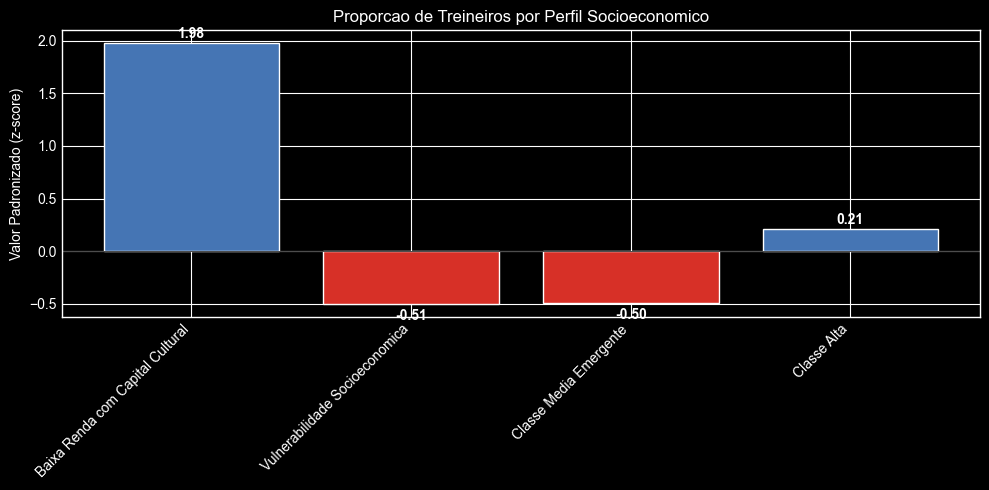

Interpretacao:
- Baixa Renda com Capital Cultural: z = +1.98 (muito ACIMA da media de treineiros)
- Classe Alta: z = +0.21 (ligeiramente acima da media)
- Vulnerabilidade Socioeconomica: z = -0.51 (abaixo da media)
- Classe Media Emergente: z = -0.50 (abaixo da media)


In [67]:
treineiro_por_perfil = df.groupby('perfil_socioeconomico')['treineiro'].mean().reindex(ordem_perfis)

plt.figure(figsize=(10, 5))
cores = ['#d73027' if v < 0 else '#4575b4' for v in treineiro_por_perfil.values]
bars = plt.bar(treineiro_por_perfil.index, treineiro_por_perfil.values, color=cores)
plt.ylabel('Valor Padronizado (z-score)')
plt.title('Proporcao de Treineiros por Perfil Socioeconomico')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(treineiro_por_perfil.values):
    posicao = v + 0.05 if v >= 0 else v - 0.15
    plt.text(i, posicao, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretacao:")
print("- Baixa Renda com Capital Cultural: z = +1.98 (muito ACIMA da media de treineiros)")
print("- Classe Alta: z = +0.21 (ligeiramente acima da media)")  
print("- Vulnerabilidade Socioeconomica: z = -0.51 (abaixo da media)")
print("- Classe Media Emergente: z = -0.50 (abaixo da media)")

### Interpretacao dos Treineiros

O perfil **Baixa Renda com Capital Cultural** apresenta a maior proporcao de treineiros (z = +1.98), seguido pela **Classe Alta** (z = +0.21). Os perfis **Vulnerabilidade Socioeconomica** e **Classe Media Emergente** tem proporcoes abaixo da media.

**Possiveis explicacoes:**
- O perfil "Baixa Renda com Capital Cultural" pode incluir estudantes mais jovens, ainda no ensino medio, cujos pais (com maior escolaridade) incentivam a realizacao do ENEM como treino
- A "Classe Alta" tambem investe em preparacao antecipada, mas em menor intensidade
- Os perfis com menor capital cultural tendem a realizar o ENEM apenas quando estao aptos a concorrer a vagas

In [68]:
resumo_perfis = df.groupby('perfil_socioeconomico').agg({
    'renda_log': 'mean',
    'esc_mae': 'mean',
    'esc_pai': 'mean',
    'total_bens': 'mean',
    'tem_computador_notebook': 'mean',
    'tem_internet_wifi': 'mean',
    'tipo_escola_D': 'mean',
    'treineiro': 'mean',
    'sexo_M': 'mean'
}).reindex(ordem_perfis)

resumo_perfis.columns = ['Renda (z)', 'Esc. Mae (z)', 'Esc. Pai (z)', 'Total Bens (z)', 
                         'Computador (z)', 'Internet (z)', 'Escola Privada (z)', 'Treineiro (z)', 'Sexo Masc (z)']

contagem = df['perfil_socioeconomico'].value_counts().reindex(ordem_perfis)
resumo_perfis['N'] = contagem.values
resumo_perfis['% Total'] = (contagem.values / len(df) * 100).round(1)

print("Tabela Resumo dos Perfis Socioeconomicos:")
print("Valores (z) sao padronizados: positivo = acima da media, negativo = abaixo da media")
resumo_perfis.round(3)

Tabela Resumo dos Perfis Socioeconomicos:
Valores (z) sao padronizados: positivo = acima da media, negativo = abaixo da media


,Renda (z),Esc. Mae (z),Esc. Pai (z),Total Bens (z),Computador (z),Internet (z),Escola Privada (z),Treineiro (z),Sexo Masc (z),N,% Total
perfil_socioeconomico,,,,,,,,,,,
Baixa Renda com Capital Cultural,-0.182,0.005,0.091,-0.229,-0.330,-0.055,-0.191,1.975,-0.130,20197,15.7
Vulnerabilidade Socioeconomica,-0.163,-0.278,-0.244,-0.362,-0.331,-0.107,-0.362,-0.506,-0.000,76299,59.4
Classe Media Emergente,0.097,-0.248,-0.412,-0.003,0.162,0.093,-0.170,-0.497,0.003,11239,8.7
Classe Alta,0.720,1.149,1.028,1.551,1.446,0.394,1.604,0.207,0.126,20811,16.2


### 10.4 Visualizacao dos Perfis no Espaco PCA (K-means, k = 4)

O grafico abaixo projeta os 128.546 participantes em duas dimensoes usando PCA (Analise de Componentes Principais). Cada ponto representa um participante, colorido de acordo com seu perfil socioeconomico. Os "X" pretos indicam os centroides (centro) de cada cluster.

**Importante:** A projecao em 2D captura apenas parte da variancia total dos dados (21.7%), entao os clusters podem estar mais separados no espaco original de 35 dimensoes.

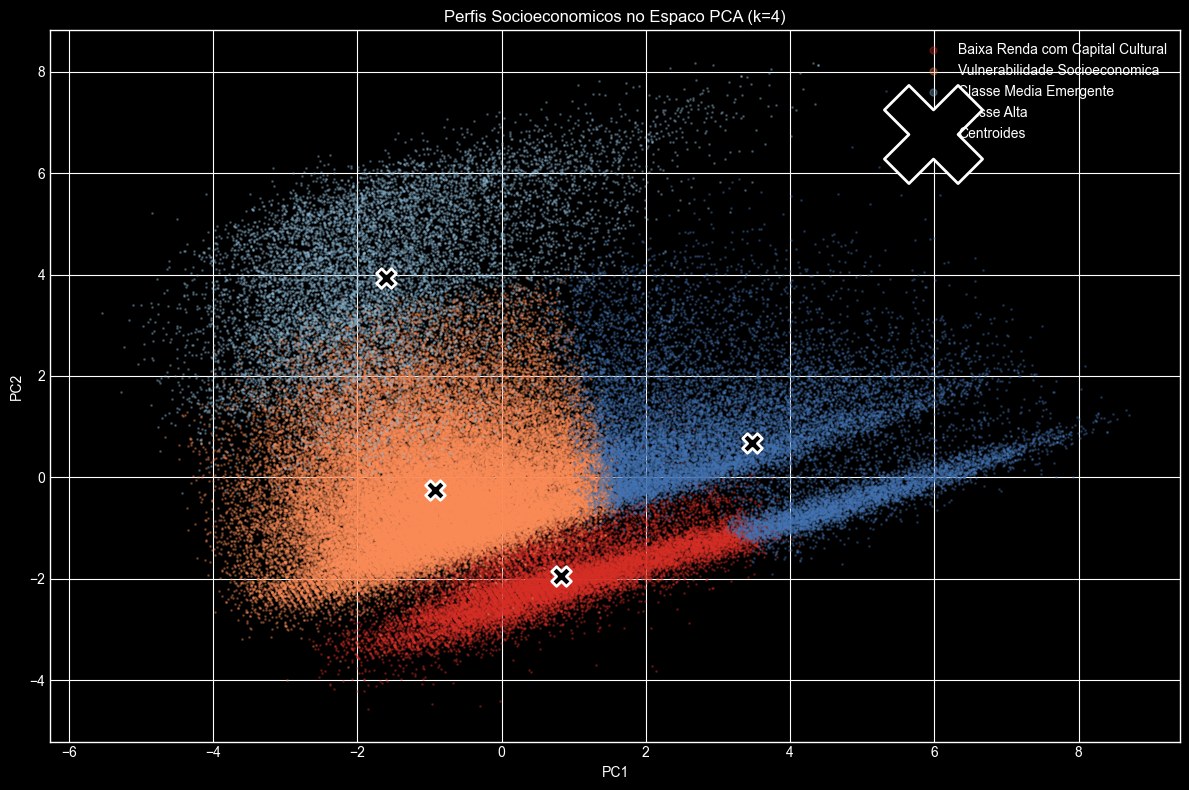

In [62]:
cores_perfis = {'Baixa Renda com Capital Cultural': '#d73027', 
                'Vulnerabilidade Socioeconomica': '#fc8d59', 
                'Classe Media Emergente': '#91bfdb', 
                'Classe Alta': '#4575b4'}

plt.figure(figsize=(12, 8))
for perfil in ordem_perfis:
    mask = df['perfil_socioeconomico'] == perfil
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=cores_perfis[perfil], label=perfil, alpha=0.3, s=1)

centroids_k4_pca = pca.transform(kmeans_4.cluster_centers_)
plt.scatter(centroids_k4_pca[:, 0], centroids_k4_pca[:, 1], 
            c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Centroides')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Perfis Socioeconomicos no Espaco PCA (k=4)')
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()

### Interpretacao da Visualizacao PCA

**O que o grafico mostra:**
- Os perfis **Vulnerabilidade Socioeconomica** (laranja) e **Baixa Renda com Capital Cultural** (vermelho) ocupam regioes proximas, indicando similaridade em algumas caracteristicas
- O perfil **Classe Alta** (azul escuro) forma um grupo mais concentrado e separado dos demais
- O perfil **Classe Media Emergente** (azul claro) apresenta maior dispersao, com sobreposicao com outros perfis

**Sobreposicao entre perfis:**
A sobreposicao visual entre os perfis e esperada porque:
1. Os dados tem 35 dimensoes, mas o grafico mostra apenas 2
2. O Silhouette Score de 0.14 indica que os clusters nao sao perfeitamente separados
3. Os perfis representam gradientes socioeconomicos, nao categorias discretas

**Centroides (X preto):**
Os centroides mostram o "ponto medio" de cada cluster. A distancia entre eles indica quao diferentes sao os perfis no espaco multidimensional.

## 11. Conclusao: Perfis Socioeconomicos dos Participantes do ENEM na Paraiba

A analise de clusterizacao identificou **quatro perfis socioeconomicos distintos** entre os participantes do ENEM na Paraiba. 

### Escolha do Algoritmo e Numero de Clusters

Apos a normalizacao de todas as variaveis (incluindo one-hot encoded), os algoritmos revelaram uma estrutura muito mais rica nos dados:

| Algoritmo | Clusters | Silhouette |
|-----------|----------|------------|
| DBSCAN (PCA 5) | 4 | **0.2901** |
| DBSCAN (PCA 15) | 68 | 0.2162 |
| K-Means (k=13) | 13 | 0.1527 |
| K-Means (k=4) | 4 | 0.1371 |

A escolha de **k=4** foi feita para permitir uma segmentacao interpretavel, alinhada com o numero de clusters do DBSCAN com PCA 5 (que obteve o melhor silhouette). Isso permite identificar perfis socioeconomicos claros e uteis para politicas publicas.

### Caracterizacao dos Perfis

#### Perfil 1: Baixa Renda com Capital Cultural (15.7%)
- **Caracteristicas:** Menor renda familiar entre os perfis, porem com escolaridade dos pais na media ou ligeiramente acima. Poucos bens no domicilio e baixo acesso a tecnologia.
- **Escola:** Predominantemente publica.
- **Interpretacao:** Familias com algum capital cultural (pais escolarizados) mas que enfrentam dificuldades economicas. Possivel indicativo de mobilidade social descendente ou familias em transicao.

#### Perfil 2: Vulnerabilidade Socioeconomica (59.4%)
- **Caracteristicas:** Maior grupo da amostra. Renda abaixo da media, escolaridade dos pais abaixo da media, **menor indice de bens** entre todos os perfis e menor acesso a tecnologia.
- **Escola:** Majoritariamente publica.
- **Interpretacao:** Grupo em situacao de maior vulnerabilidade global, com deficit tanto economico quanto de capital cultural. Representa a maioria dos participantes do ENEM na Paraiba.

#### Perfil 3: Classe Media Emergente (8.7%)
- **Caracteristicas:** Renda acima da media, porem com escolaridade dos pais abaixo da media (especialmente do pai). Bom acesso a tecnologia e bens proximos da media.
- **Escola:** Predominantemente publica.
- **Interpretacao:** Familias em ascensao economica, onde os filhos estao superando o nivel educacional dos pais. Indicativo de mobilidade social ascendente.

#### Perfil 4: Classe Alta (16.2%)
- **Caracteristicas:** Maior renda familiar, pais com escolaridade bem acima da media, maior indice de bens, amplo acesso a tecnologia.
- **Escola:** Maior proporcao em escolas privadas.
- **Treineiros:** Maior proporcao de treineiros, indicando estrategias de preparacao antecipada.
- **Interpretacao:** Grupo com maior capital economico e cultural, com acesso privilegiado a recursos educacionais.

### Implicacoes para Politicas Publicas

1. **Vulnerabilidade majoritaria:** O perfil de Vulnerabilidade Socioeconomica representa quase 60% dos participantes, indicando que a maioria dos candidatos ao ENEM na Paraiba vem de contextos com deficit tanto economico quanto de capital cultural.

2. **Acesso a tecnologia:** Os perfis de Baixa Renda com Capital Cultural e Vulnerabilidade Socioeconomica apresentam deficit significativo no acesso a computadores e internet, o que pode impactar negativamente a preparacao para o ENEM.

3. **Mobilidade social:** A existencia do perfil Classe Media Emergente (8.7%) sugere que ha familias em processo de ascensao economica, onde os filhos buscam no ENEM uma oportunidade de consolidar essa mobilidade atraves do ensino superior.

4. **Capital cultural vs economico:** O perfil Baixa Renda com Capital Cultural revela que escolaridade dos pais e renda familiar nao estao perfeitamente correlacionados, sugerindo que programas de apoio devem considerar ambas as dimensoes.

5. **Desigualdade nas estrategias de preparacao:** A maior proporcao de treineiros no perfil Classe Alta indica que familias com mais recursos investem em preparacao antecipada para o ENEM.

6. **Escola publica x privada:** A forte correlacao entre perfil socioeconomico e tipo de escola reforca o papel da educacao publica no atendimento a populacao mais vulneravel.

### Notas Metodologicas

- **Algoritmo escolhido:** K-Means com k=4, por oferecer melhor interpretabilidade para o problema.
- **Silhouette Score (k=4):** 0.1371 - inferior ao k=13 (0.1527), mas a segmentacao em 4 perfis e mais interpretavel.
- **DBSCAN:** Apos a normalizacao de todas as variaveis, identificou **166 clusters** nos dados originais e **4 clusters** com PCA 5 componentes (silhouette 0.29). Isso revela que os dados possuem estrutura multi-cluster, nao binaria como parecia antes da normalizacao.
- **Comparativo:** O DBSCAN com PCA 5 obteve o melhor silhouette (0.29), seguido pelo DBSCAN com PCA 15 (0.22) e K-Means k=13 (0.15).
- **Variancia explicada (PCA 2D):** A visualizacao em 2D captura apenas parte da variancia total, portanto os clusters podem ser mais separados no espaco original de 35 dimensoes.
- **Valores padronizados:** Todas as variaveis foram padronizadas (z-score) antes da clusterizacao. Valores positivos indicam acima da media geral, negativos indicam abaixo.

In [63]:
print("="*70)
print("RESUMO FINAL: PERFIS SOCIOECONOMICOS DO ENEM NA PARAIBA")
print("="*70)

for perfil in ordem_perfis:
    n = len(df[df['perfil_socioeconomico'] == perfil])
    pct = n / len(df) * 100
    print(f"\n{perfil}:")
    print(f"  Participantes: {n:,} ({pct:.1f}%)")
    
print("\n" + "="*70)
print(f"Total de participantes analisados: {len(df):,}")
print("="*70)

RESUMO FINAL: PERFIS SOCIOECONOMICOS DO ENEM NA PARAIBA

Baixa Renda com Capital Cultural:
  Participantes: 20,197 (15.7%)

Vulnerabilidade Socioeconomica:
  Participantes: 76,299 (59.4%)

Classe Media Emergente:
  Participantes: 11,239 (8.7%)

Classe Alta:
  Participantes: 20,811 (16.2%)

Total de participantes analisados: 128,546


In [69]:
df.to_csv('dados_com_clusters_e_perfis.csv', index=False)
print("Dados com perfis socioeconomicos salvos em 'dados_com_clusters_e_perfis.csv'")

Dados com perfis socioeconomicos salvos em 'dados_com_clusters_e_perfis.csv'
